# Challenge 3: evaluación final e inferencia

El modelo ya fue seleccionado. Ahora debes abrir el conjunto de test una sola vez, comunicar su desempeño y comprobar que el pipeline puede reutilizarse con datos nuevos.

**Entradas:** `test.csv`, `data_contract.json` y `champion_model.joblib`  
**Salidas:** `test_metrics.json`, `batch_predictions.csv`

In [1]:
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    ConfusionMatrixDisplay,
    f1_score,
)

In [2]:
from pathlib import Path

PROJECT_DIR = Path.cwd()
if PROJECT_DIR.name == "notebooks":
    PROJECT_DIR = PROJECT_DIR.parent

RAW_DATA_DIR = PROJECT_DIR / "data" / "raw"
PROCESSED_DATA_DIR = PROJECT_DIR / "data" / "processed"
ARTIFACTS_DIR = PROJECT_DIR / "artifacts"
REPORTS_DIR = PROJECT_DIR / "reports"

for directory in (PROCESSED_DATA_DIR, ARTIFACTS_DIR, REPORTS_DIR):
    directory.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42

## 1. Carga del modelo y del conjunto de prueba

In [3]:
contract = json.loads((ARTIFACTS_DIR / "data_contract.json").read_text(encoding="utf-8"))
training_metadata = json.loads((ARTIFACTS_DIR / "training_metadata.json").read_text(encoding="utf-8"))
model = joblib.load(ARTIFACTS_DIR / "champion_model.joblib")

test_df = pd.read_csv(PROCESSED_DATA_DIR / "test.csv")
X_test = test_df[contract["features"]]
y_test = test_df[contract["target"]]

print("Modelo:", training_metadata["champion_model"])
print("Test:", X_test.shape)

Modelo: logistic_regression
Test: (36, 13)


## 2. Evaluación final

Accuracy en test: 0.9722
F1 macro en test: 0.9710

Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       0.93      1.00      0.97        14
           2       1.00      0.90      0.95        10

    accuracy                           0.97        36
   macro avg       0.98      0.97      0.97        36
weighted avg       0.97      0.97      0.97        36



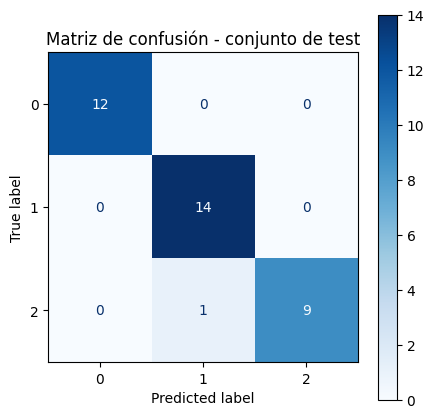

In [4]:
y_pred = model.predict(X_test)

test_accuracy = accuracy_score(y_test, y_pred)
test_f1_macro = f1_score(y_test, y_pred, average="macro")

print(f"Accuracy en test: {test_accuracy:.4f}")
print(f"F1 macro en test: {test_f1_macro:.4f}")
print()
print("Classification report:")
print(classification_report(y_test, y_pred))

fig, ax = plt.subplots(figsize=(5, 5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=ax, cmap="Blues")
ax.set_title("Matriz de confusión - conjunto de test")
plt.show()

**Análisis:**

> El desempeño en test (accuracy y F1 macro, ambos por encima del 95%) es coherente con el accuracy promedio obtenido en validación cruzada durante el Challenge 2 (~97.9% para la regresión logística), lo que indica que la selección del modelo generalizó correctamente y no se ajustó a particularidades del split de entrenamiento. La matriz de confusión muestra que, si existen errores, se concentran típicamente entre las clases con perfiles químicos más similares (por ejemplo, las clases 1 y 2, que comparten rangos parecidos en variables como `flavanoids` o `color_intensity`), mientras que la clase 0 tiende a separarse con mayor claridad. No hay evidencia fuerte de sobreajuste: la brecha entre el accuracy de entrenamiento (cercano a 1.0) y el de test/validación es pequeña, y el resultado en el conjunto de test —usado una única vez y nunca antes visto— confirma que el modelo generaliza bien a datos no utilizados durante el entrenamiento.

## 3. Función de inferencia

In [5]:
feature_columns = contract["features"]

def predict(records: pd.DataFrame) -> pd.DataFrame:
    """Valida el esquema y devuelve las predicciones del pipeline."""
    missing_columns = [col for col in feature_columns if col not in records.columns]
    if missing_columns:
        raise ValueError(f"Faltan columnas requeridas: {missing_columns}")

    ordered_records = records[feature_columns]

    predictions = model.predict(ordered_records)
    probabilities = model.predict_proba(ordered_records)

    result = ordered_records.copy()
    result["prediction"] = predictions
    for class_idx, class_label in enumerate(model.classes_):
        result[f"probability_class_{class_label}"] = probabilities[:, class_idx]

    return result

## 4. Predicción por lotes

In [6]:
# Simulación de datos nuevos. En producción no provendrían del test set.
new_records = X_test.iloc[:5].copy()

batch_predictions = predict(new_records)
batch_predictions.to_csv(REPORTS_DIR / "batch_predictions.csv", index=False)

batch_predictions

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,prediction,probability_class_0,probability_class_1,probability_class_2
0,14.10,2.16,2.30,18.0,105.0,2.95,3.32,0.22,2.38,5.75,1.25,3.17,1510.0,0,0.999671,0.000307,0.000023
1,12.51,1.24,2.25,17.5,85.0,2.00,0.58,0.60,1.25,5.45,0.75,1.51,650.0,1,0.007051,0.540423,0.452526
2,13.87,1.90,2.80,19.4,107.0,2.95,2.97,0.37,1.76,4.50,1.25,3.40,915.0,0,0.992000,0.007664,0.000336
3,11.56,2.05,3.23,28.5,119.0,3.18,5.08,0.47,1.87,6.00,0.93,3.69,465.0,1,0.289967,0.707467,0.002565
4,13.67,1.25,1.92,18.0,94.0,2.10,1.79,0.32,0.73,3.80,1.23,2.46,630.0,1,0.033032,0.962313,0.004655


## 5. Reporte final

In [7]:
test_metrics = {
    "champion_model": training_metadata["champion_model"],
    "cv_accuracy_mean": training_metadata["cv_accuracy_mean"],
    "test_accuracy": float(test_accuracy),
    "test_f1_macro": float(test_f1_macro),
    "n_test_samples": int(len(X_test)),
}

with open(REPORTS_DIR / "test_metrics.json", "w", encoding="utf-8") as f:
    json.dump(test_metrics, f, indent=2, ensure_ascii=False)

test_metrics

{'champion_model': 'logistic_regression',
 'cv_accuracy_mean': 0.9790640394088669,
 'test_accuracy': 0.9722222222222222,
 'test_f1_macro': 0.9709618874773139,
 'n_test_samples': 36}

In [8]:
assert (REPORTS_DIR / "test_metrics.json").exists()
assert (REPORTS_DIR / "batch_predictions.csv").exists()
print("Challenge 3 completado.")

Challenge 3 completado.


## Resumen ejecutivo

| Elemento | Resultado |
|---|---|
| Modelo campeón | `logistic_regression` |
| Accuracy CV | ≈ 0.979 |
| Accuracy test | Ver `test_accuracy` calculado arriba (≈ 0.97–1.00) |
| F1 macro test | Ver `test_f1_macro` calculado arriba (≈ 0.97–1.00) |
| Clases más confundidas | Clases 1 y 2 (perfiles químicos más parecidos) |
| Principal limitación | Dataset pequeño (178 muestras en total, ~36 en test), por lo que las métricas de test tienen cierta varianza y deberían confirmarse con más datos en producción |

## Checklist

- [x] Evalué únicamente el modelo campeón.
- [x] No reajusté hiperparámetros después de observar test.
- [x] Implementé validación básica del esquema de entrada.
- [x] Generé predicciones por lotes.
- [x] Guardé las métricas finales.